In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Step 3 outputs
sessions = pd.read_csv("C:\\Users\\Yash\\OneDrive\\Desktop\\Yash\\Evision\\Evision\\Files\\Code Generated CSV\\sessions_master.csv")
stations = pd.read_csv("C:\\Users\\Yash\\OneDrive\\Desktop\\Yash\\Evision\\Evision\\station_aggregates.csv")

print("Sessions shape:", sessions.shape)
print("Stations shape:", stations.shape)


Sessions shape: (314, 22)
Stations shape: (236, 17)


In [5]:
# Compute demand features at station level
demand_features = sessions.groupby('station_key').agg({
    'energy_consumed_kwh': 'mean',
    'charging_duration_hours': 'mean',
    'state_of_charge_start': 'mean',
    'state_of_charge_end': 'mean'
}).reset_index()

# Calculate SOC delta (avg)
demand_features['avg_soc_delta'] = demand_features['state_of_charge_end'] - demand_features['state_of_charge_start']

# Weekend share
sessions['is_weekend'] = sessions['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_share = sessions.groupby('station_key')['is_weekend'].mean().reset_index().rename(columns={'is_weekend': 'weekend_share'})

# Merge weekend share
demand_features = demand_features.merge(weekend_share, on='station_key', how='left')

demand_features.head()


,station_key,energy_consumed_kwh,charging_duration_hours,state_of_charge_start,state_of_charge_end,avg_soc_delta,weekend_share
0,"1059/1060,_adarsh_nagar,_near_infinity_mall,_o...",34.005201,5.11,29.482598,68.169258,38.686660,0.000000
1,"12th_road,_above_upadhyaya_nursing_home,_santa...",47.767847,1.45,13.709454,97.589405,83.879952,0.000000
2,"14,_jp_rd,_aram_nagar,_seven_bunglow,_andheri_...",55.302731,1.48,71.916646,88.375242,16.458596,0.000000
3,"157,_jeevan_bima_marg,_backbay_reclamation,_ch...",33.549890,3.39,39.097371,77.367959,38.270588,0.666667
4,"2/7_meghal_industrial_estate,_devidayal_road,_...",30.013724,4.35,43.608499,91.764837,48.156338,0.000000


In [6]:
# Merge demand features with supply (station aggregates)
feature_df = stations.merge(demand_features, on='station_key', how='left')

# Handle NaNs (if any)
feature_df.fillna(0, inplace=True)

feature_df.head()


,station_key,station_name,charging_station_operator,energy_consumed_kwh_sum,energy_consumed_kwh_mean,charging_duration_hours_mean,charging_rate_kw_mean,sessions_count,popular_vehicle_model,peak_time_of_day,...,city,state,charging_station_location,stations_within_2km,energy_consumed_kwh,charging_duration_hours,state_of_charge_start,state_of_charge_end,avg_soc_delta,weekend_share
0,"1059/1060,_adarsh_nagar,_near_infinity_mall,_o...","1059/1060, Adarsh nagar, near infinity mall, O...",Ather,56.115093,56.115093,10.22,5.488040,3,Hyundai Kona,Night,...,Mumbai,Maharashtra,"1059/1060, Adarsh nagar, near infinity mall, O...",4,34.005201,5.11,29.482598,68.169258,38.686660,0.0
1,"1059/1060,_adarsh_nagar,_near_infinity_mall,_o...","1059/1060, Adarsh nagar, near infinity mall, O...",Tata Power,5.163807,5.163807,0.98,5.265203,3,Hyundai Kona,Night,...,Mumbai,Maharashtra,"1059/1060, Adarsh nagar, near infinity mall, O...",4,34.005201,5.11,29.482598,68.169258,38.686660,0.0
2,"1059/1060,_adarsh_nagar,_near_infinity_mall,_o...","1059/1060, Adarsh nagar, near infinity mall, O...",Volttic,40.736705,40.736705,4.13,9.866759,3,Hyundai Kona,Night,...,Mumbai,Maharashtra,"1059/1060, Adarsh nagar, near infinity mall, O...",4,34.005201,5.11,29.482598,68.169258,38.686660,0.0
3,"12th_road,_above_upadhyaya_nursing_home,_santa...","12th Road, Above Upadhyaya Nursing Home, Santa...",Tata Power,47.767847,47.767847,1.45,32.994342,1,MG Comet,Night,...,Mumbai,Maharashtra,"12th Road, Above Upadhyaya Nursing Home, Santa...",2,47.767847,1.45,13.709454,97.589405,83.879952,0.0
4,"14,_jp_rd,_aram_nagar,_seven_bunglow,_andheri_...","14, JP Rd, Aram Nagar, Seven Bunglow, Andheri ...",Jio-bp Pulse,55.302731,55.302731,1.48,37.347461,1,TATA Tiago,Morning,...,Mumbai,Maharashtra,"14, JP Rd, Aram Nagar, Seven Bunglow, Andheri ...",5,55.302731,1.48,71.916646,88.375242,16.458596,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select features for scoring
score_cols = ['sessions_count', 'energy_consumed_kwh_mean', 'charging_duration_hours_mean', 'avg_soc_delta', 'stations_within_2km']
scaler = MinMaxScaler()
feature_df[[col + '_norm' for col in score_cols]] = scaler.fit_transform(feature_df[score_cols])

# Compute weighted score
feature_df['suitability_score'] = (
    0.35 * feature_df['sessions_count_norm'] +
    0.25 * feature_df['energy_consumed_kwh_mean_norm'] +
    0.15 * feature_df['avg_soc_delta_norm'] +
    0.10 * feature_df['charging_duration_hours_mean_norm'] +
    0.15 * (1 - feature_df['stations_within_2km_norm'])  # fewer nearby stations = better
)

feature_df[['station_key', 'suitability_score']].sort_values(by='suitability_score', ascending=False).head(10)


,station_key,suitability_score
89,"iocl_sahara_hospitality,_vile_parle,_opp._dome...",0.783760
84,"iocl_sahara_hospitality,_vile_parle,_opp._dome...",0.757644
53,"cr_-_lokmanya_tilak_station,_kurla,_outside_pl...",0.752181
88,"iocl_sahara_hospitality,_vile_parle,_opp._dome...",0.744773
70,"fortune_cars,_navi_mumbai,_plot_no._d-400,_ttc...",0.736878
87,"iocl_sahara_hospitality,_vile_parle,_opp._dome...",0.732142
52,"cr_-_lokmanya_tilak_station,_kurla,_outside_pl...",0.727598
68,"fortune_cars,_navi_mumbai,_plot_no._d-400,_ttc...",0.724248
49,"cr_-_lokmanya_tilak_station,_kurla,_outside_pl...",0.713194
69,"fortune_cars,_navi_mumbai,_plot_no._d-400,_ttc...",0.713120


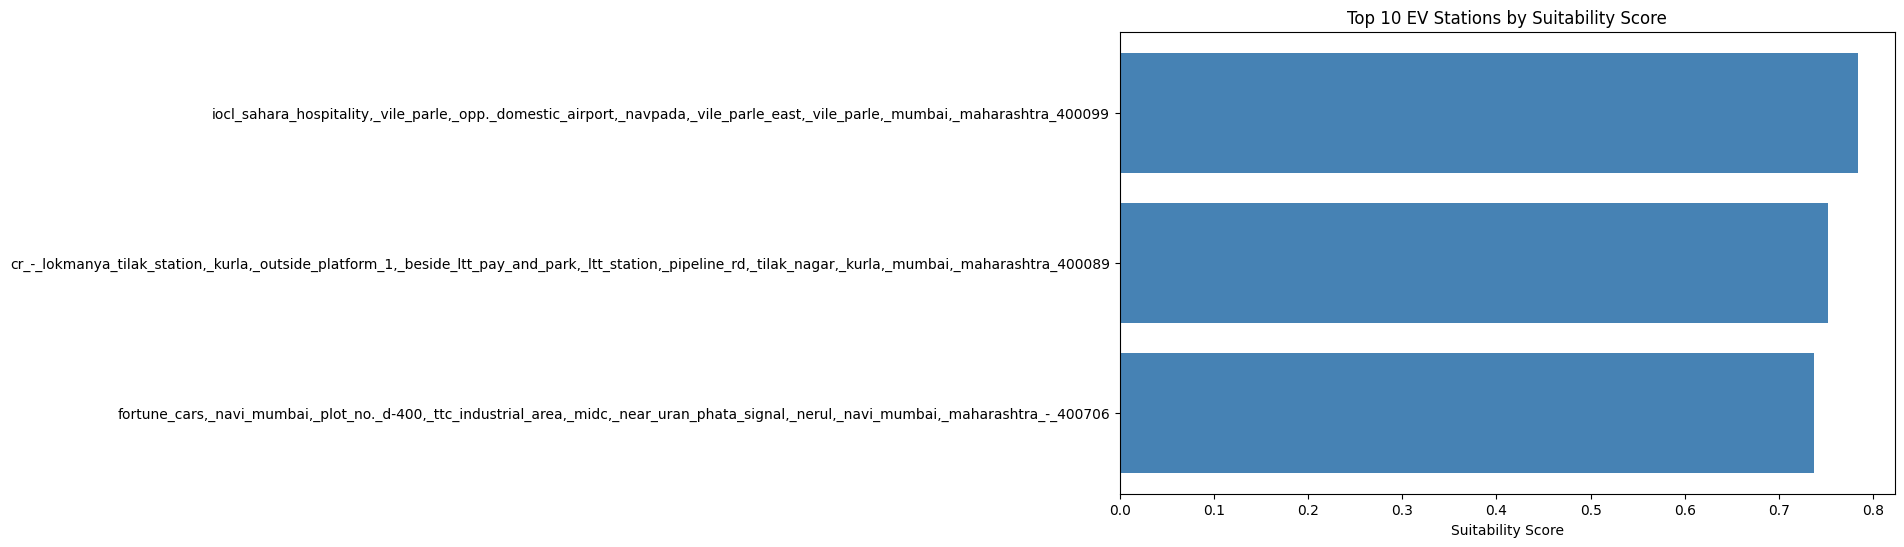

In [8]:
# Export final dataset
feature_df.to_csv("station_suitability_scores.csv", index=False)

# Bar plot for Top 10 stations
top10 = feature_df.sort_values(by='suitability_score', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top10['station_key'], top10['suitability_score'], color='steelblue')
plt.xlabel("Suitability Score")
plt.title("Top 10 EV Stations by Suitability Score")
plt.gca().invert_yaxis()
plt.show()


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


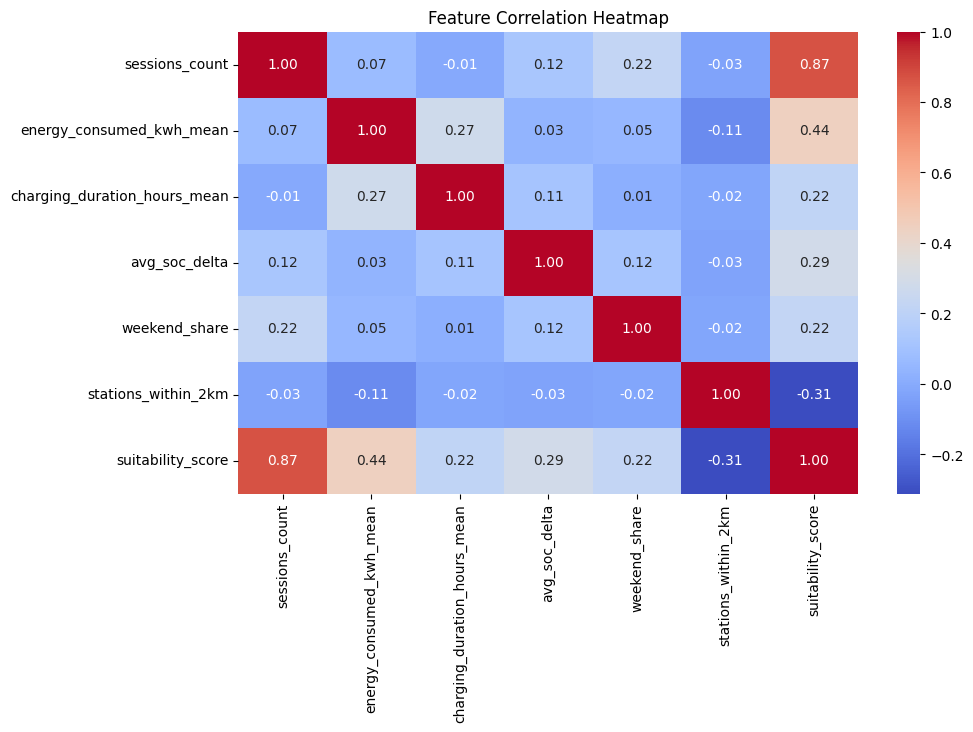


Correlation with Suitability Score:
suitability_score               1.000000
sessions_count                  0.868919
energy_consumed_kwh_mean        0.443857
avg_soc_delta                   0.287420
weekend_share                   0.223455
charging_duration_hours_mean    0.216199
stations_within_2km            -0.311181
Name: suitability_score, dtype: float64


In [9]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation
corr_features = ['sessions_count', 'energy_consumed_kwh_mean', 'charging_duration_hours_mean',
                 'avg_soc_delta', 'weekend_share', 'stations_within_2km', 'suitability_score']

# Compute correlation matrix
corr_matrix = feature_df[corr_features].corr()

# Display correlation matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Print sorted correlation with suitability_score
print("\nCorrelation with Suitability Score:")
print(corr_matrix['suitability_score'].sort_values(ascending=False))
